# 📊 Customer Churn Prediction (Telco)
## Introduction to Machine Learning for Data Science

Цей проєкт демонструє повний цикл ML-задачі: від аналізу даних до побудови та оцінки моделей.

## 1. Завантаження та опис даних
Датасет містить інформацію про клієнтів телеком-компанії та факт їх відтоку (Churn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Очистка даних

In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

df = df.drop('customerID', axis=1)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
d

## 3. Кодування даних

In [3]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 4. EDA (Аналіз даних)

### Баланс класів

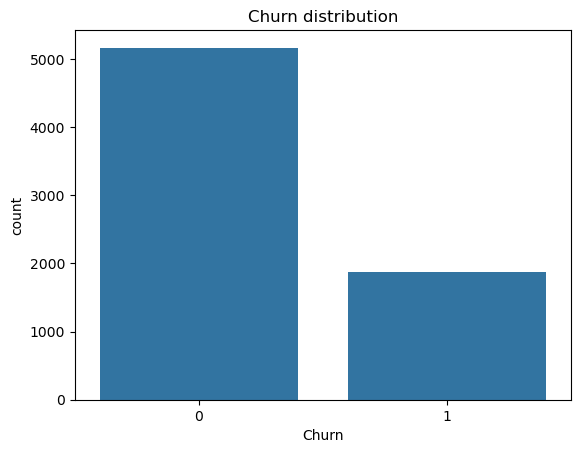

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [4]:
sns.countplot(x='Churn', data=df)
plt.title("Churn distribution")
plt.show()

print(df['Churn'].value_counts(normalize=True))

### Кореляції

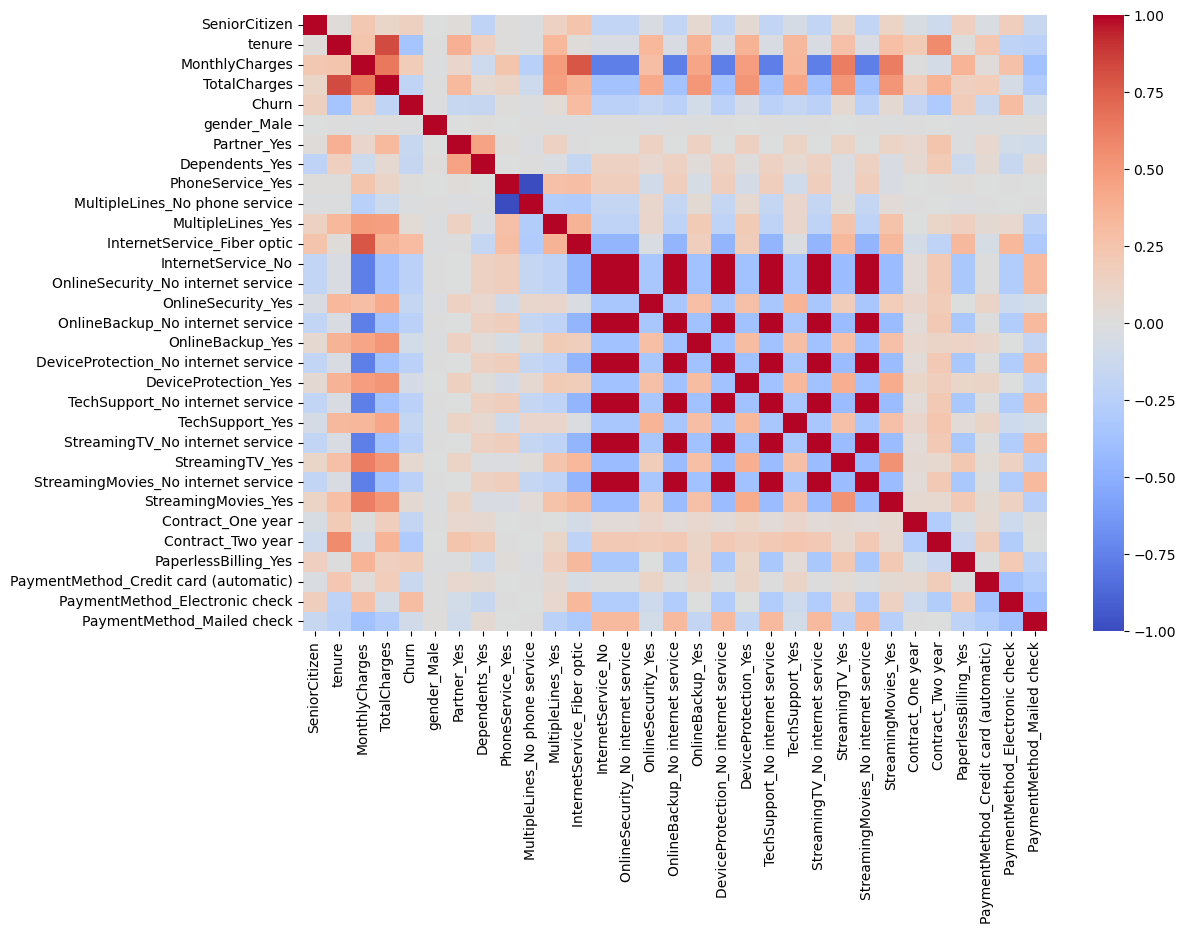

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

### Аналіз ключових факторів

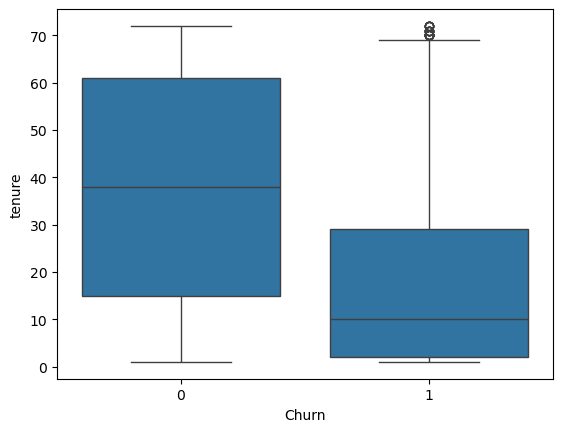

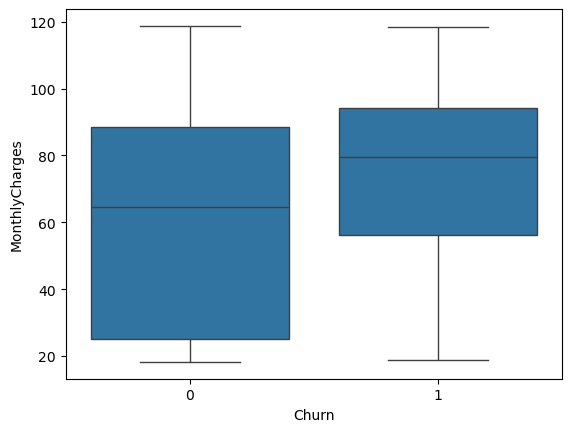

In [6]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

## 5. Розбиття даних

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Побудова моделей

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Моделі
lr = LogisticRegression(max_iter=2000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# Навчання
lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)  # RF не потребує scaling

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Оцінка моделей

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, lr_pred))

print("Random Forest:")
print(classification_report(y_test, rf_pred))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## 8. Важливість ознак

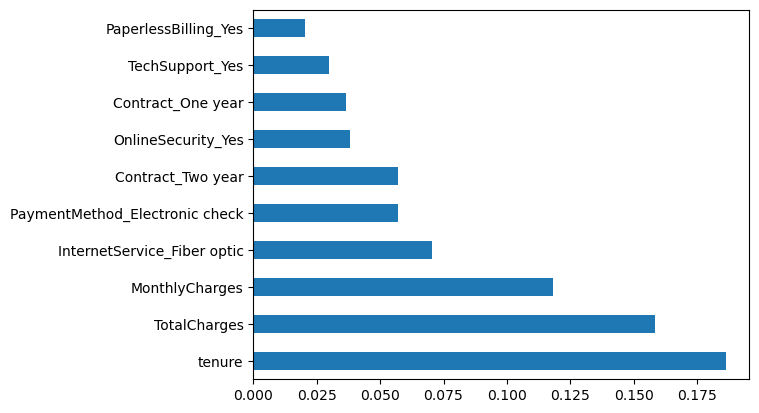

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

## 9. Висновки

- Random Forest показав кращий баланс метрик
- Найважливіші фактори: Contract, MonthlyCharges, tenure
- Модель може бути використана для прогнозування відтоку клієнтів
